# Import libraries

In [1]:
import os
import random
import joblib
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset

from transformers import Trainer, TrainingArguments

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import kagglehub

In [2]:
SEED = 42
N_SPLITS = 5
TEST_SIZE = 0.2

In [3]:
def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

set_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Download & EDA dataset

In [4]:
# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [5]:
df = pd.read_csv(path + "/Data/features_3_sec.csv")

In [6]:
display(df.head())

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [7]:
df = df.drop(labels="filename",axis=1)

In [8]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   length                   9990 non-null   int64  
 1   chroma_stft_mean         9990 non-null   float64
 2   chroma_stft_var          9990 non-null   float64
 3   rms_mean                 9990 non-null   float64
 4   rms_var                  9990 non-null   float64
 5   spectral_centroid_mean   9990 non-null   float64
 6   spectral_centroid_var    9990 non-null   float64
 7   spectral_bandwidth_mean  9990 non-null   float64
 8   spectral_bandwidth_var   9990 non-null   float64
 9   rolloff_mean             9990 non-null   float64
 10  rolloff_var              9990 non-null   float64
 11  zero_crossing_rate_mean  9990 non-null   float64
 12  zero_crossing_rate_var   9990 non-null   float64
 13  harmony_mean             9990 non-null   float64
 14  harmony_var             

None

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
length,9990.0,6.614900e+04,0.000000e+00,6.614900e+04,66149.000000,6.614900e+04,6.614900e+04,6.614900e+04
chroma_stft_mean,9990.0,3.795341e-01,9.046576e-02,1.071078e-01,0.315698,3.847409e-01,4.424433e-01,7.494808e-01
chroma_stft_var,9990.0,8.487615e-02,9.636622e-03,1.534475e-02,0.079833,8.510794e-02,9.109229e-02,1.209643e-01
rms_mean,9990.0,1.308591e-01,6.854539e-02,9.534877e-04,0.083782,1.212534e-01,1.763277e-01,4.425668e-01
rms_var,9990.0,2.676388e-03,3.585628e-03,4.379535e-08,0.000615,1.491318e-03,3.130862e-03,3.261522e-02
spectral_centroid_mean,9990.0,2.199219e+03,7.518606e+02,4.727416e+02,1630.680158,2.208628e+03,2.712582e+03,5.432534e+03
spectral_centroid_var,9990.0,4.166727e+05,4.349644e+05,8.118813e+02,123196.130771,2.650692e+05,5.624152e+05,4.794119e+06
spectral_bandwidth_mean,9990.0,2.241386e+03,5.438544e+02,4.991629e+02,1887.455790,2.230576e+03,2.588341e+03,3.708148e+03
spectral_bandwidth_var,9990.0,1.182711e+05,1.013505e+05,1.183520e+03,48765.526957,8.996072e+04,1.585674e+05,1.235143e+06
rolloff_mean,9990.0,4.566077e+03,1.642065e+03,6.583363e+02,3378.311110,4.631378e+03,5.591635e+03,9.487446e+03


In [10]:
display(df.duplicated().sum())

np.int64(133)

In [11]:
df = df.drop_duplicates()

In [12]:
classes = df['label'].unique()
label2id = {label: i for i, label in enumerate(classes)}
id2label = {i: label for label, i in label2id.items()}

df['label'] = df['label'].map(label2id)

In [13]:
X = df.drop(labels="label",axis=1)
y = df["label"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7885, 58) (7885,)
Test: (1972, 58) (1972,)


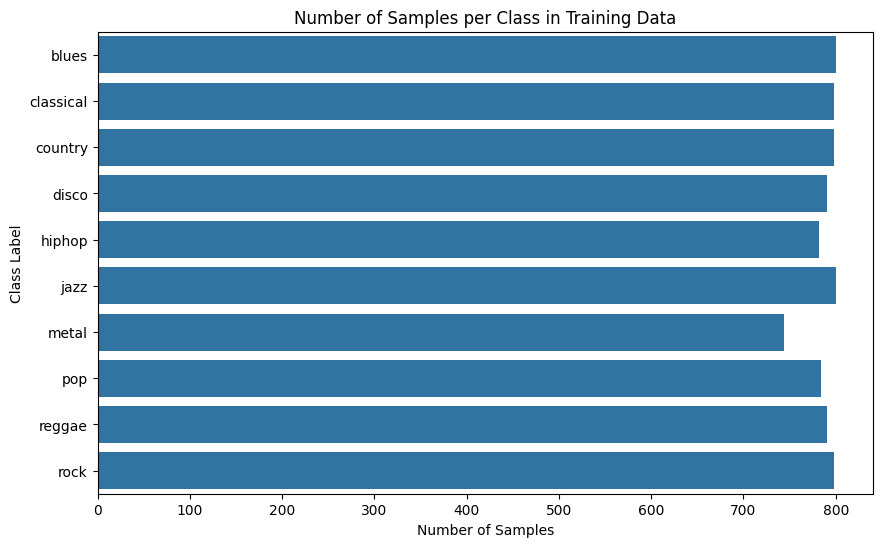

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(y=y_train.map(id2label), order=list(id2label.values()))
plt.title('Number of Samples per Class in Training Data')
plt.xlabel('Number of Samples')
plt.ylabel('Class Label')
plt.show()

# Utils

In [16]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

In [17]:
def evaluate_ml(model, X_eval, y_eval, plot=False):
    y_pred = model.predict(X_eval)

    f1 = f1_score(y_eval, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_eval, y_pred, average="macro", zero_division=0)

    print(f"Macro F1:        {f1:.4f}")
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall:    {recall:.4f}")

    labels = sorted(id2label.keys())
    class_names = [id2label[i] for i in labels]

    if plot:
        cm = confusion_matrix(y_eval, y_pred, labels=labels)

        plt.figure(figsize=(12, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

        print(
            classification_report(
                y_eval,
                y_pred,
                target_names=class_names,
                zero_division=0
            )
        )

    return {
        "f1": f1,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    }

In [18]:
def build_knn():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", KNeighborsClassifier())
        ]
    )

In [19]:
def build_svm():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                SVC(
                    probability=True,
                    random_state=SEED
                )
            )
        ]
    )

In [20]:
def build_xgb():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                XGBClassifier(
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                    random_state=SEED,
                    n_jobs=-1
                )
            )
        ]
    )

In [21]:
def build_lgb():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LGBMClassifier(
                    random_state=SEED,
                    n_jobs=-1,
                    verbose=-1
                )
            )
        ]
    )

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

# 2. Machine Learning

## 2.1. KNN

KNN CV Macro F1 (Weights): 0.8671

Macro F1:        0.8778
Accuracy:        0.8773
Macro Precision: 0.8795
Macro Recall:    0.8777


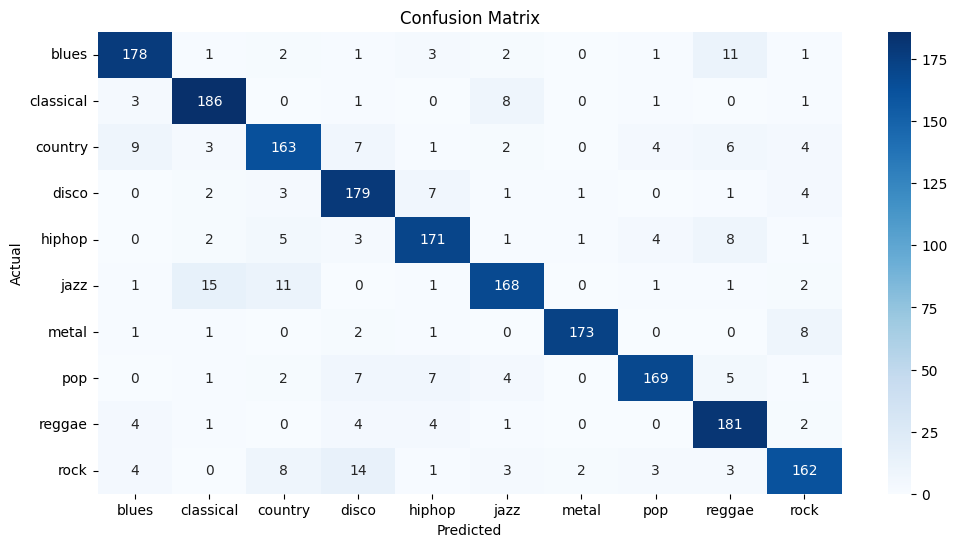

              precision    recall  f1-score   support

       blues       0.89      0.89      0.89       200
   classical       0.88      0.93      0.90       200
     country       0.84      0.82      0.83       199
       disco       0.82      0.90      0.86       198
      hiphop       0.87      0.87      0.87       196
        jazz       0.88      0.84      0.86       200
       metal       0.98      0.93      0.95       186
         pop       0.92      0.86      0.89       196
      reggae       0.84      0.92      0.88       197
        rock       0.87      0.81      0.84       200

    accuracy                           0.88      1972
   macro avg       0.88      0.88      0.88      1972
weighted avg       0.88      0.88      0.88      1972



In [23]:
knn_model = build_knn()

# Calculate CV score for weighting
knn_cv_f1 = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
).mean()
print(f"KNN CV Macro F1 (Weights): {knn_cv_f1:.4f}\n")

knn_model.fit(X_train, y_train)

knn_result = evaluate_ml(
    knn_model,
    X_test,
    y_test,
    plot=True
)

## 2.2. SVM

SVM CV Macro F1 (Weights): 0.8428

Macro F1:        0.8511
Accuracy:        0.8509
Macro Precision: 0.8529
Macro Recall:    0.8511


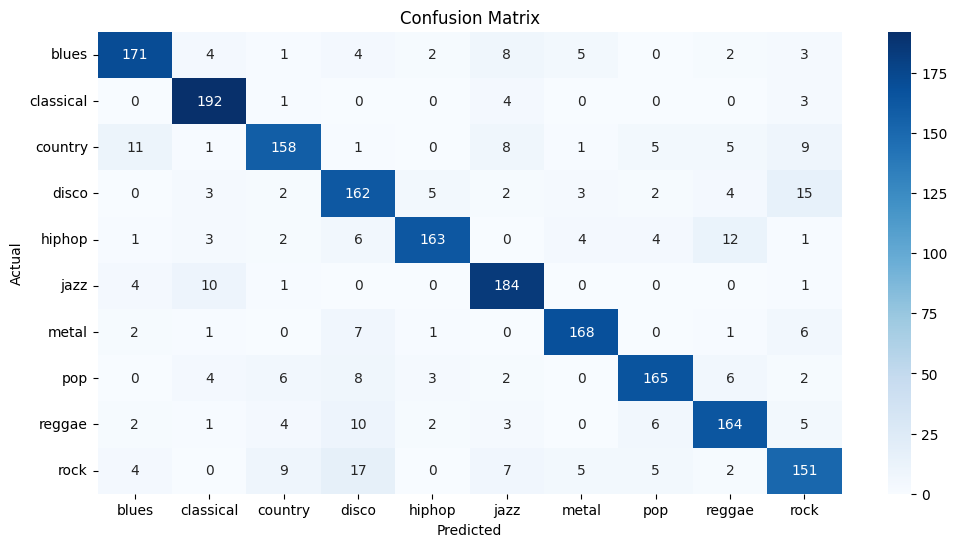

              precision    recall  f1-score   support

       blues       0.88      0.85      0.87       200
   classical       0.88      0.96      0.92       200
     country       0.86      0.79      0.83       199
       disco       0.75      0.82      0.78       198
      hiphop       0.93      0.83      0.88       196
        jazz       0.84      0.92      0.88       200
       metal       0.90      0.90      0.90       186
         pop       0.88      0.84      0.86       196
      reggae       0.84      0.83      0.83       197
        rock       0.77      0.76      0.76       200

    accuracy                           0.85      1972
   macro avg       0.85      0.85      0.85      1972
weighted avg       0.85      0.85      0.85      1972



In [24]:
svm_model = build_svm()

# Calculate CV score for weighting
svm_cv_f1 = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
).mean()
print(f"SVM CV Macro F1 (Weights): {svm_cv_f1:.4f}\n")

svm_model.fit(X_train, y_train)

svm_result = evaluate_ml(
    svm_model,
    X_test,
    y_test,
    plot=True
)

## 2.3. XGBoost

XGB CV Macro F1 (Weights): 0.8871

Macro F1:        0.9002
Accuracy:        0.9001
Macro Precision: 0.9007
Macro Recall:    0.9002


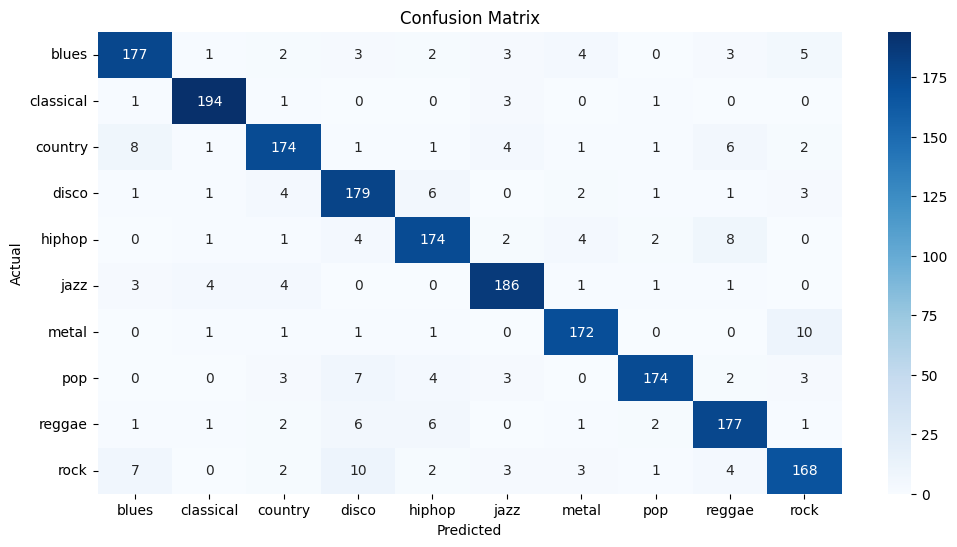

              precision    recall  f1-score   support

       blues       0.89      0.89      0.89       200
   classical       0.95      0.97      0.96       200
     country       0.90      0.87      0.89       199
       disco       0.85      0.90      0.88       198
      hiphop       0.89      0.89      0.89       196
        jazz       0.91      0.93      0.92       200
       metal       0.91      0.92      0.92       186
         pop       0.95      0.89      0.92       196
      reggae       0.88      0.90      0.89       197
        rock       0.88      0.84      0.86       200

    accuracy                           0.90      1972
   macro avg       0.90      0.90      0.90      1972
weighted avg       0.90      0.90      0.90      1972



In [25]:
xgb_model = build_xgb()

# Calculate CV score for weighting
xgb_cv_f1 = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro'
).mean()
print(f"XGB CV Macro F1 (Weights): {xgb_cv_f1:.4f}\n")

xgb_model.fit(X_train, y_train)

xgb_result = evaluate_ml(
    xgb_model,
    X_test,
    y_test,
    plot=True
)

## 2.4. LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB CV Macro F1 (Weights): 0.8952



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1:        0.9070
Accuracy:        0.9067
Macro Precision: 0.9082
Macro Recall:    0.9067


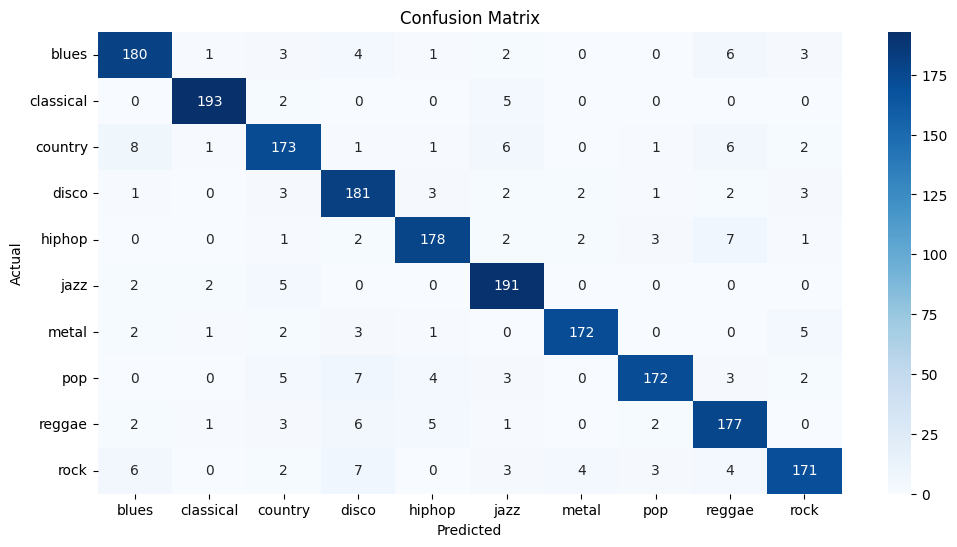

              precision    recall  f1-score   support

       blues       0.90      0.90      0.90       200
   classical       0.97      0.96      0.97       200
     country       0.87      0.87      0.87       199
       disco       0.86      0.91      0.89       198
      hiphop       0.92      0.91      0.92       196
        jazz       0.89      0.95      0.92       200
       metal       0.96      0.92      0.94       186
         pop       0.95      0.88      0.91       196
      reggae       0.86      0.90      0.88       197
        rock       0.91      0.85      0.88       200

    accuracy                           0.91      1972
   macro avg       0.91      0.91      0.91      1972
weighted avg       0.91      0.91      0.91      1972



In [26]:
lgb_model = build_lgb()

# Calculate CV score for weighting
lgb_cv_f1 = cross_val_score(
    lgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_macro'
).mean()
print(f"LGB CV Macro F1 (Weights): {lgb_cv_f1:.4f}\n")

lgb_model.fit(X_train, y_train)

lgb_result = evaluate_ml(
    lgb_model,
    X_test,
    y_test,
    plot=True
)

## 2.5. Ensemble

### 2.5.1. Hard Voting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1:        0.9136
Accuracy:        0.9138
Macro Precision: 0.9153
Macro Recall:    0.9138


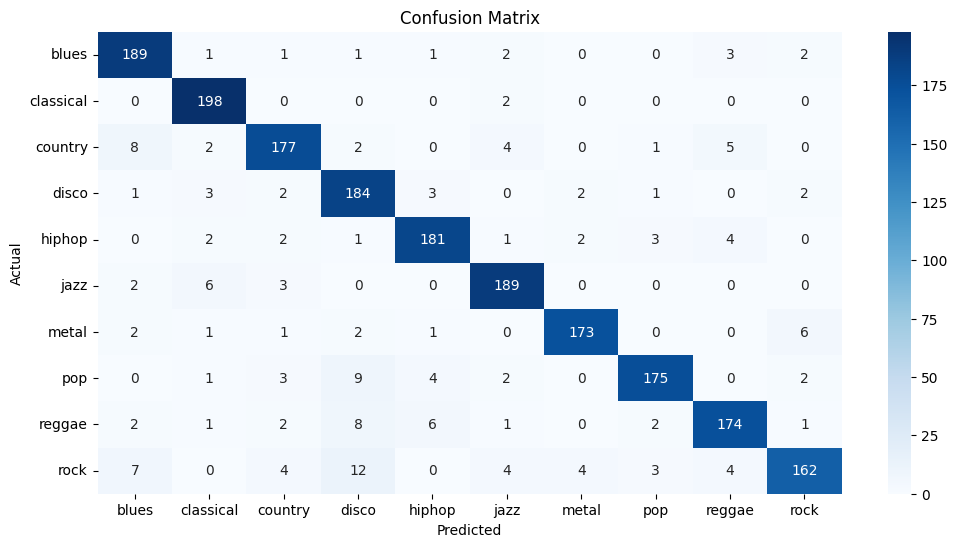

              precision    recall  f1-score   support

       blues       0.90      0.94      0.92       200
   classical       0.92      0.99      0.95       200
     country       0.91      0.89      0.90       199
       disco       0.84      0.93      0.88       198
      hiphop       0.92      0.92      0.92       196
        jazz       0.92      0.94      0.93       200
       metal       0.96      0.93      0.94       186
         pop       0.95      0.89      0.92       196
      reggae       0.92      0.88      0.90       197
        rock       0.93      0.81      0.86       200

    accuracy                           0.91      1972
   macro avg       0.92      0.91      0.91      1972
weighted avg       0.92      0.91      0.91      1972



In [27]:
hard_voting_clf = VotingClassifier(
    estimators=[
        ("knn", build_knn()),
        ("svm", build_svm()),
        ("xgb", build_xgb()),
        ("lgb", build_lgb())
    ],
    voting="hard"
)

hard_voting_clf.fit(X_train, y_train)

hard_voting_result = evaluate_ml(
    hard_voting_clf,
    X_test,
    y_test,
    plot=True
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1:        0.9189
Accuracy:        0.9189
Macro Precision: 0.9197
Macro Recall:    0.9189


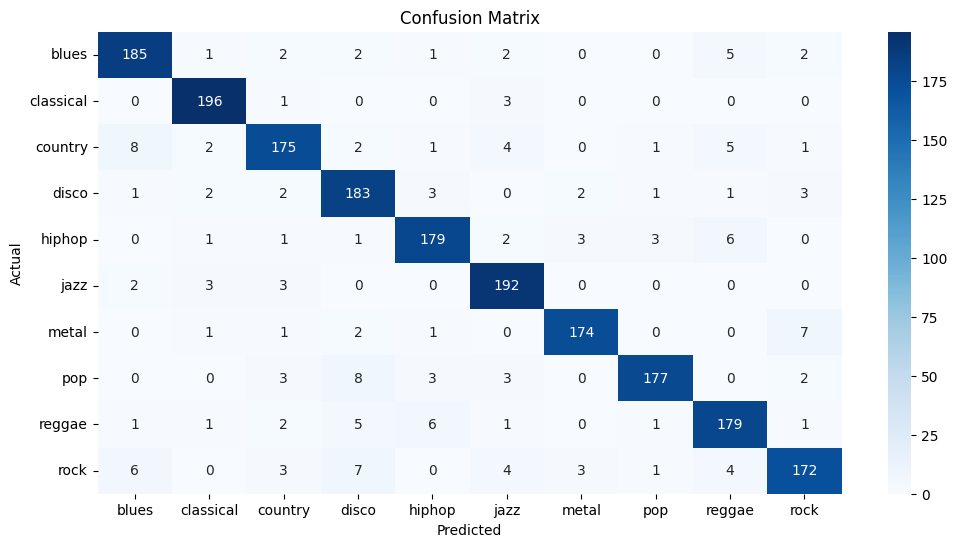

              precision    recall  f1-score   support

       blues       0.91      0.93      0.92       200
   classical       0.95      0.98      0.96       200
     country       0.91      0.88      0.89       199
       disco       0.87      0.92      0.90       198
      hiphop       0.92      0.91      0.92       196
        jazz       0.91      0.96      0.93       200
       metal       0.96      0.94      0.95       186
         pop       0.96      0.90      0.93       196
      reggae       0.90      0.91      0.90       197
        rock       0.91      0.86      0.89       200

    accuracy                           0.92      1972
   macro avg       0.92      0.92      0.92      1972
weighted avg       0.92      0.92      0.92      1972



In [28]:
hard_voting_weight_clf = VotingClassifier(
    estimators=[
        ("knn", build_knn()),
        ("svm", build_svm()),
        ("xgb", build_xgb()),
        ("lgb", build_lgb())
    ],
    voting="hard",
    weights=[
        knn_cv_f1,
        svm_cv_f1,
        xgb_cv_f1,
        lgb_cv_f1
    ]
)

hard_voting_weight_clf.fit(X_train, y_train)

hard_voting_weight_result = evaluate_ml(
    hard_voting_weight_clf,
    X_test,
    y_test,
    plot=True
)

### 2.5.2. Soft Voting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1:        0.9244
Accuracy:        0.9244
Macro Precision: 0.9249
Macro Recall:    0.9245


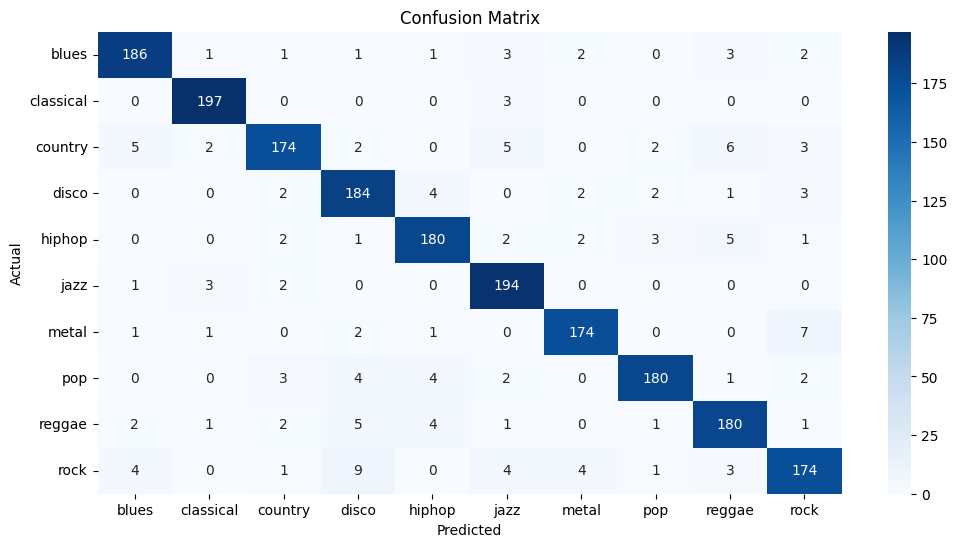

              precision    recall  f1-score   support

       blues       0.93      0.93      0.93       200
   classical       0.96      0.98      0.97       200
     country       0.93      0.87      0.90       199
       disco       0.88      0.93      0.91       198
      hiphop       0.93      0.92      0.92       196
        jazz       0.91      0.97      0.94       200
       metal       0.95      0.94      0.94       186
         pop       0.95      0.92      0.94       196
      reggae       0.90      0.91      0.91       197
        rock       0.90      0.87      0.89       200

    accuracy                           0.92      1972
   macro avg       0.92      0.92      0.92      1972
weighted avg       0.92      0.92      0.92      1972



In [29]:
soft_voting_clf = VotingClassifier(
    estimators=[
        ("knn", build_knn()),
        ("svm", build_svm()),
        ("xgb", build_xgb()),
        ("lgb", build_lgb())
    ],
    voting="soft",
)

soft_voting_clf.fit(X_train, y_train)

soft_voting_result = evaluate_ml(
    soft_voting_clf,
    X_test,
    y_test,
    plot=True
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Macro F1:        0.9259
Accuracy:        0.9260
Macro Precision: 0.9264
Macro Recall:    0.9260


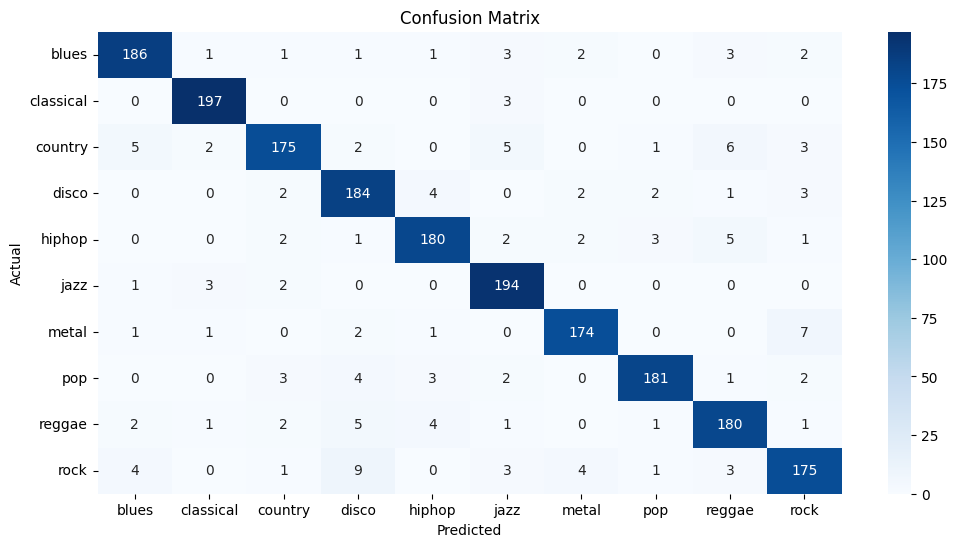

              precision    recall  f1-score   support

       blues       0.93      0.93      0.93       200
   classical       0.96      0.98      0.97       200
     country       0.93      0.88      0.90       199
       disco       0.88      0.93      0.91       198
      hiphop       0.93      0.92      0.93       196
        jazz       0.91      0.97      0.94       200
       metal       0.95      0.94      0.94       186
         pop       0.96      0.92      0.94       196
      reggae       0.90      0.91      0.91       197
        rock       0.90      0.88      0.89       200

    accuracy                           0.93      1972
   macro avg       0.93      0.93      0.93      1972
weighted avg       0.93      0.93      0.93      1972



In [30]:
soft_voting_weight_clf = VotingClassifier(
    estimators=[
        ("knn", build_knn()),
        ("svm", build_svm()),
        ("xgb", build_xgb()),
        ("lgb", build_lgb())
    ],
    voting="soft",
    weights=[
        knn_cv_f1,
        svm_cv_f1,
        xgb_cv_f1,
        lgb_cv_f1
    ]
)

soft_voting_weight_clf.fit(X_train, y_train)

soft_voting_weight_result = evaluate_ml(
    soft_voting_weight_clf,
    X_test,
    y_test,
    plot=True
)

# 3. Deep learning (MLP)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
class MusicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "features": self.X[idx],
            "labels": self.y[idx]
        }

train_dataset = MusicDataset(X_train, y_train)
test_dataset = MusicDataset(X_test, y_test)

In [33]:
class MLPForClassification(nn.Module):
    def __init__(self, input_size, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.RMSNorm(512),
            nn.SiLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.RMSNorm(256),
            nn.SiLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.RMSNorm(128),
            nn.SiLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, features, labels=None):
        logits = self.net(features)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

In [34]:
input_size = X_train.shape[1]
num_classes = len(id2label)

model = MLPForClassification(
    input_size=input_size,
    num_classes=num_classes
)

In [35]:
batch_size = 512
steps_per_epoch = math.ceil(len(train_dataset) / batch_size)
eval_steps = steps_per_epoch * 50

In [36]:
training_args = TrainingArguments(
    output_dir="content/mlp_trainer",
    num_train_epochs=500,

    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,

    learning_rate=2e-3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    logging_strategy="steps",
    logging_steps=eval_steps,

    eval_strategy="steps",
    eval_steps=eval_steps,

    save_strategy="steps",
    save_steps=eval_steps,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",

    seed=SEED,
    data_seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [37]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
800,0.534325,0.287786,0.917850,0.918005,0.918729,0.918055
1600,0.069118,0.329254,0.920385,0.920894,0.923839,0.920514
2400,0.035283,0.312555,0.932049,0.932132,0.932578,0.932223
3200,0.023043,0.319671,0.937120,0.937313,0.937543,0.937304
4000,0.017801,0.315796,0.937120,0.937204,0.937872,0.937339
4800,0.010724,0.314652,0.939655,0.939851,0.940432,0.939771
5600,0.007751,0.330809,0.945233,0.945298,0.945562,0.945287
6400,0.005618,0.299865,0.943712,0.943839,0.944319,0.943744
7200,0.004430,0.304650,0.947262,0.947291,0.947635,0.947315
8000,0.003983,0.303261,0.946247,0.946288,0.946696,0.946315


TrainOutput(global_step=8000, training_loss=0.07120759388804436, metrics={'train_runtime': 68.5481, 'train_samples_per_second': 57514.396, 'train_steps_per_second': 116.706, 'total_flos': 0.0, 'train_loss': 0.07120759388804436, 'epoch': 500.0})

Macro F1:        0.9473
Accuracy:        0.9473
Macro Precision: 0.9476
Macro Recall:    0.9473


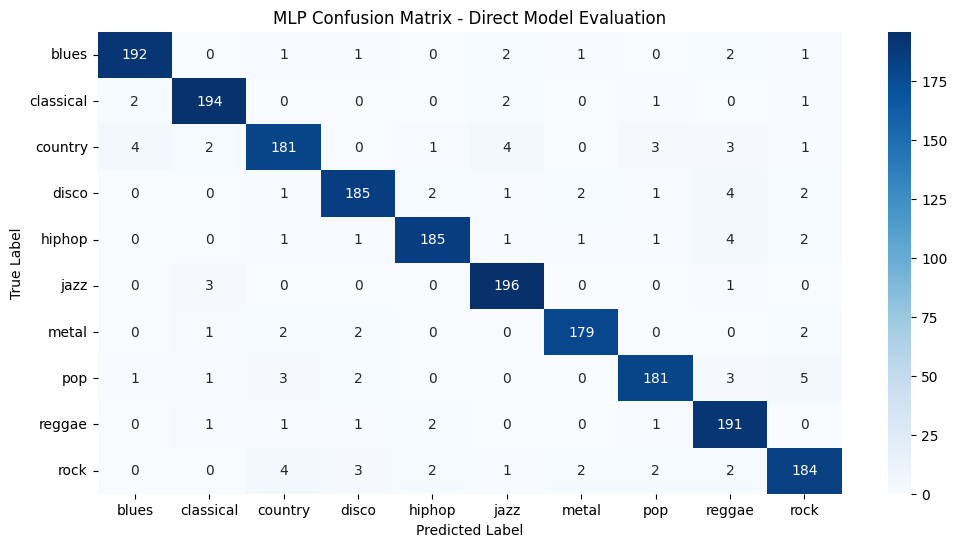

              precision    recall  f1-score   support

       blues       0.96      0.96      0.96       200
   classical       0.96      0.97      0.97       200
     country       0.93      0.91      0.92       199
       disco       0.95      0.93      0.94       198
      hiphop       0.96      0.94      0.95       196
        jazz       0.95      0.98      0.96       200
       metal       0.97      0.96      0.96       186
         pop       0.95      0.92      0.94       196
      reggae       0.91      0.97      0.94       197
        rock       0.93      0.92      0.92       200

    accuracy                           0.95      1972
   macro avg       0.95      0.95      0.95      1972
weighted avg       0.95      0.95      0.95      1972



In [38]:
model.to(device)
model.eval()

# --- Predict on test_dataset ---
with torch.no_grad():
    test_features = test_dataset.X.to(device)
    test_labels = test_dataset.y.to(device)

    outputs = model(features=test_features)
    y_logits = outputs["logits"].cpu().numpy()
    y_true = test_labels.cpu().numpy()
    y_preds = np.argmax(y_logits, axis=1)

f1 = f1_score(y_true, y_preds, average="macro", zero_division=0)
accuracy = accuracy_score(y_true, y_preds)
precision = precision_score(y_true, y_preds, average="macro", zero_division=0)
recall = recall_score(y_true, y_preds, average="macro", zero_division=0)

print(f"Macro F1:        {f1:.4f}")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")

labels = sorted(id2label.keys())
class_names = [id2label[i] for i in labels]

cm = confusion_matrix(y_true, y_preds, labels=labels)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MLP Confusion Matrix - Direct Model Evaluation")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(classification_report(
    y_true,
    y_preds,
    target_names=class_names,
    zero_division=0
))